# **Emotion Classification Using Fine-Tuned XLNet Transformer Model**

### 1. Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
from cleantext import clean
import re
from transformers import XLNetTokenizer, XLNetForSequenceClassification, TrainingArguments, Trainer, pipeline
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import datasets 
import evaluate
import random

Since the GPL-licensed package `unidecode` is not installed, using Python's `unicodedata` package which yields worse results.


### 2. Loading and Preprocessing the Dataset

In [2]:
data_train = pd.read_csv('emotion-labels-test.csv') 
data_test = pd.read_csv('emotion-labels-test.csv')
data_val = pd.read_csv('emotion-labels-test.csv')
# data should be saved in a folder called 'emotions' which is saved in the same place as your notebook

In [3]:
data_train.head()

,text,label
0,You must be knowing #blithe means (adj.) Happ...,joy
1,Old saying 'A #smile shared is one gained for ...,joy
2,Bridget Jones' Baby was bloody hilarious 😅 #Br...,joy
3,@Elaminova sparkling water makes your life spa...,joy
4,I'm tired of everybody telling me to chill out...,joy


In [4]:
data = pd.concat([data_train, data_test, data_val], ignore_index=True)

In [5]:
data['text_clean'] = data['text'].apply(lambda x: clean(x, no_emoji=True))

In [6]:
data['text_clean'] = data['text_clean'].apply(lambda x: re.sub('@[^\s]+', '', x))

data.head(20)

### 3. Balancing the Dataset and Encoding Labels

<Axes: xlabel='label'>

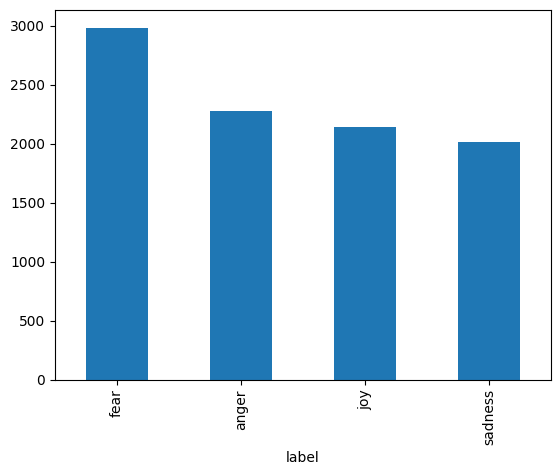

In [8]:
data['label'].value_counts().plot(kind="bar")

In [9]:
g = data.groupby('label')
data = pd.DataFrame(g.apply(lambda x: x.sample(g.size().min()).reset_index(drop=True)))

C:\Users\iqraf\AppData\Local\Temp\ipykernel_30460\2135407547.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = pd.DataFrame(g.apply(lambda x: x.sample(g.size().min()).reset_index(drop=True)))


<Axes: xlabel='label'>

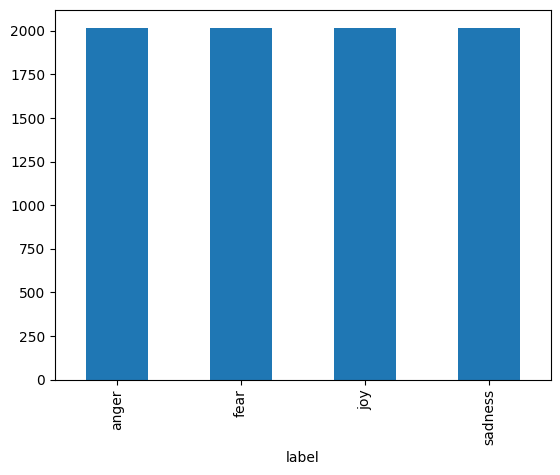

In [10]:
data['label'].value_counts().plot(kind="bar")

In [11]:
data['label_int'] = LabelEncoder().fit_transform(data['label'])

In [12]:

NUM_LABELS = 4

### 4. Splitting the Dataset

In [13]:

train_split, test_split = train_test_split(data, train_size = 0.8)
train_split, val_split = train_test_split(train_split, train_size = 0.9)

In [14]:
print(len(train_split))
print(len(test_split))
print(len(val_split))

5814
1616
646


### 5. Preparing Hugging Face Dataset Format

In [15]:
train_df = pd.DataFrame({
    "label": train_split.label_int.values,
    "text": train_split.text_clean.values
})

test_df = pd.DataFrame({
    "label": test_split.label_int.values,
    "text": test_split.text_clean.values
})

In [16]:
train_df = datasets.Dataset.from_dict(train_df)
test_df = datasets.Dataset.from_dict(test_df)

In [17]:
dataset_dict = datasets.DatasetDict({"train":train_df, "test":test_df})

In [18]:
dataset_dict

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 5814
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 1616
    })
})

### 6.Tokenization and Creating Input Embeddings

In [19]:
tokenizer = XLNetTokenizer.from_pretrained("xlnet-base-cased")

In [20]:
def tokenize_function(examples):
    return tokenizer(examples["text"], padding = "max_length", max_length = 128, truncation=True)

In [21]:
tokenized_datasets = dataset_dict.map(tokenize_function, batched=True)

Map:   0%|          | 0/5814 [00:00<?, ? examples/s]

Map:   0%|          | 0/1616 [00:00<?, ? examples/s]

In [22]:

tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['label', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 5814
    })
    test: Dataset({
        features: ['label', 'text', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1616
    })
})

### 7.Understanding Tokenized Features

In [23]:
print(tokenized_datasets['train']['text'][0])

  also a


In [24]:

print(tokenized_datasets['train']['input_ids'][0])

[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 77, 24, 4, 3]


In [25]:
tokenizer.decode(5)

'<pad>'

In [26]:
print(tokenized_datasets['train']['token_type_ids'][0])

[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 0, 0, 0, 2]


In [27]:
print(tokenized_datasets['train']['attention_mask'][0])

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1]


### 8. Creating Smaller Training and Evaluation Datasets

In [28]:

small_train_dataset = tokenized_datasets["train"].shuffle(seed=42).select(range(100))
small_eval_dataset = tokenized_datasets["test"].shuffle(seed=42).select(range(100))

### 9. Loading and Configuring the XLNet Model

In [29]:
model = XLNetForSequenceClassification.from_pretrained('xlnet-base-cased', 
                                                       num_labels=NUM_LABELS, 
                                                       id2label={0: 'anger', 1: 'fear', 2: 'joy', 3: 'sadness'})

Some weights of XLNetForSequenceClassification were not initialized from the model checkpoint at xlnet-base-cased and are newly initialized: ['logits_proj.bias', 'logits_proj.weight', 'sequence_summary.summary.bias', 'sequence_summary.summary.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


### 10. Defining Evaluation Metrics and Training Arguments

In [30]:
metric = evaluate.load("accuracy")

In [31]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

In [33]:
training_args = TrainingArguments(output_dir="test_trainer", eval_strategy="epoch", num_train_epochs=3)

### 11. Training the XLNet Model

In [34]:
trainer = Trainer(
    model=model, 
    args=training_args,
    train_dataset=small_train_dataset,
    eval_dataset=small_eval_dataset,
    compute_metrics=compute_metrics)

In [35]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.428225,0.320000
2,No log,1.297264,0.400000
3,No log,1.311206,0.390000


TrainOutput(global_step=39, training_loss=1.3646253928160057, metrics={'train_runtime': 126.3498, 'train_samples_per_second': 2.374, 'train_steps_per_second': 0.309, 'total_flos': 21366375321600.0, 'train_loss': 1.3646253928160057, 'epoch': 3.0})

### 12. Evaluating and Saving the Model

In [36]:
trainer.evaluate()

{'eval_loss': 1.311206340789795,
 'eval_accuracy': 0.39,
 'eval_runtime': 8.5527,
 'eval_samples_per_second': 11.692,
 'eval_steps_per_second': 1.52,
 'epoch': 3.0}

In [37]:
model.save_pretrained("fine_tuned_model")

### 13. Loading the Saved Model and Performing Inference

In [38]:
fine_tuned_model = XLNetForSequenceClassification.from_pretrained("fine_tuned_model")

In [39]:
clf = pipeline("text-classification", fine_tuned_model, tokenizer=tokenizer)

Device set to use cpu


In [40]:
rand_int = random.randint(0, len(val_split))
print(val_split['text_clean'][rand_int])
answer = clf(val_split['text_clean'][rand_int], top_k=None)
print(answer)

the outrage over kessel's tweet by butthurt usa players is hilarious.
[{'label': 'sadness', 'score': 0.35618776082992554}, {'label': 'joy', 'score': 0.3391822576522827}, {'label': 'fear', 'score': 0.18621321022510529}, {'label': 'anger', 'score': 0.11841673403978348}]


C:\Users\iqraf\AppData\Local\Temp\ipykernel_30460\3116462782.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(val_split['text_clean'][rand_int])
C:\Users\iqraf\AppData\Local\Temp\ipykernel_30460\3116462782.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  answer = clf(val_split['text_clean'][rand_int], top_k=None)
